In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/242B/FinalProject/data/coco
!mkdir -p /content/drive/MyDrive/242B/FinalProject/data/negbench/images
%cd /content/drive/MyDrive/242B/FinalProject/data/coco

!wget -nc http://images.cocodataset.org/zips/val2017.zip
!unzip -q -n val2017.zip

/content/drive/MyDrive/242B/FinalProject/data/coco
File ‘val2017.zip’ already there; not retrieving.

^C


In [ ]:
# 1. clone NegBench
%cd /content/
!git clone https://github.com/m1k2zoo/negbench.git

# 2. install
%cd /content/negbench/benchmarks
!pip install -e .
!pip install -q transformers datasets torch torchvision pillow pandas tqdm scikit-learn matplotlib open_clip_torch

# 3. mount drive
!mkdir -p /content/drive/MyDrive/242B/FinalProject/data/negbench/images

/content
fatal: destination path 'negbench' already exists and is not an empty directory.
/content/negbench/benchmarks
Obtaining file:///content/negbench/benchmarks
  Preparing metadata (setup.py) ... done
  Attempting uninstall: open_clip_torch
    Found existing installation: open_clip_torch 2.24.0
    Uninstalling open_clip_torch-2.24.0:
      Successfully uninstalled open_clip_torch-2.24.0
  Running setup.py develop for open_clip_torch


In [ ]:
import os
import re
import glob
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

OUTPUT_DIR = "/content/drive/MyDrive/242B_negbench_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# Find NegBench COCO MCQ CSV
# -----------------------------
csvs = glob.glob("/content/drive/MyDrive/**/*.csv", recursive=True)

candidate_csvs = [
    p for p in csvs
    if "COCO_val_mcq" in os.path.basename(p)
    and "rephrased" in os.path.basename(p)
]

print("Candidate NegBench COCO MCQ CSVs:")
for p in candidate_csvs:
    print(p)

if len(candidate_csvs) == 0:
    raise FileNotFoundError(
        "Cannot find COCO_val_mcq...csv in Google Drive. "
        "Please check whether the NegBench image CSV has been uploaded."
    )

NEGBENCH_CSV = candidate_csvs[0]
print("\nUsing CSV:", NEGBENCH_CSV)

# -----------------------------
# Find COCO val2017 image folder
# -----------------------------
coco_imgs = glob.glob("/content/drive/MyDrive/**/val2017/*.jpg", recursive=True)

print("Number of COCO images found:", len(coco_imgs))
print("Example images:", coco_imgs[:3])

if len(coco_imgs) == 0:
    raise FileNotFoundError(
        "Cannot find COCO val2017 images in Google Drive. "
        "Please check whether COCO/val2017/*.jpg exists."
    )

COCO_DIR = os.path.dirname(coco_imgs[0])
print("COCO_DIR:", COCO_DIR)

DEVICE: cuda
Candidate NegBench COCO MCQ CSVs:
/content/drive/MyDrive/242B/FinalProject/data/negbench/images/COCO_val_mcq_llama3.1_rephrased.csv

Using CSV: /content/drive/MyDrive/242B/FinalProject/data/negbench/images/COCO_val_mcq_llama3.1_rephrased.csv
Number of COCO images found: 5000
Example images: ['/content/drive/MyDrive/242B/FinalProject/data/coco/val2017/000000140076.jpg', '/content/drive/MyDrive/242B/FinalProject/data/coco/val2017/000000218439.jpg', '/content/drive/MyDrive/242B/FinalProject/data/coco/val2017/000000571598.jpg']
COCO_DIR: /content/drive/MyDrive/242B/FinalProject/data/coco/val2017


In [ ]:
df_raw = pd.read_csv(NEGBENCH_CSV)

print("Raw shape:", df_raw.shape)
print("Columns:")
print(df_raw.columns.tolist())
display(df_raw.head())

Raw shape: (5914, 7)
Columns:
['image_path', 'correct_answer', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'correct_answer_template']


,image_path,correct_answer,caption_0,caption_1,caption_2,caption_3,correct_answer_template
0,data/coco/images/val2017/000000397133.jpg,0,"This image features a knife, but no car is pre...","A car is present in this image, but there is n...",This image features a car,This image does not feature a knife.,hybrid
1,data/coco/images/val2017/000000397133.jpg,0,A chair is not present in this image.,"This image shows a chair, but no spoon is pres...",A chair is present in this image.,A spoon is not included in this image.,negative
2,data/coco/images/val2017/000000397133.jpg,0,"A person is present in this image, but there's...","This image shows a fork, with no person in sight.",A fork is shown in this image.,No person is present in this image.,hybrid
3,data/coco/images/val2017/000000397133.jpg,0,No car is present in this image.,"This image features a car, but there is no spoon.",A car is present in this image.,No spoon is visible in this image.,negative
4,data/coco/images/val2017/000000397133.jpg,0,A sink and a spoon are included in this image.,"A car is present in this image, but a sink is ...",This image features a car.,A sink is not present in this image.,positive


In [ ]:
def infer_image_col(df):
    candidates = [
        "image_path", "filepath", "file_path", "img_path",
        "image", "image_file", "filename", "file_name",
        "coco_path", "path"
    ]
    for col in candidates:
        if col in df.columns:
            return col

    # fallback: any column containing image/path/file
    for col in df.columns:
        lc = col.lower()
        if ("image" in lc or "path" in lc or "file" in lc) and df[col].dtype == object:
            return col

    # sometimes only image_id exists
    for col in df.columns:
        lc = col.lower()
        if "image_id" in lc or lc == "id":
            return col

    return None


def infer_answer_col(df):
    candidates = [
        "answer", "correct_answer", "correct", "label",
        "gt", "ground_truth", "target", "correct_option"
    ]
    for col in candidates:
        if col in df.columns:
            return col

    for col in df.columns:
        lc = col.lower()
        if "answer" in lc or "correct" in lc or "label" in lc:
            return col

    return None


def infer_option_cols(df, answer_col=None, image_col=None):
    cols = list(df.columns)

    # common MCQ format: A, B, C, D
    letter_cols = [c for c in ["A", "B", "C", "D", "E", "F"] if c in cols]
    if len(letter_cols) >= 2:
        return letter_cols

    # lowercase
    letter_cols = [c for c in ["a", "b", "c", "d", "e", "f"] if c in cols]
    if len(letter_cols) >= 2:
        return letter_cols

    # option_0, option_1, caption_0, choice_0
    pattern_cols = []
    for col in cols:
        lc = col.lower()
        if (
            re.match(r"^(option|choice|caption|answer_option)[_\-\s]?\d+$", lc)
            or re.match(r"^(option|choice|caption)[_\-\s]?[a-f]$", lc)
        ):
            pattern_cols.append(col)

    if len(pattern_cols) >= 2:
        def sort_key(c):
            nums = re.findall(r"\d+", c)
            if nums:
                return int(nums[-1])
            letters = re.findall(r"[a-fA-F]$", c)
            if letters:
                return ord(letters[-1].lower()) - ord("a")
            return 999
        return sorted(pattern_cols, key=sort_key)

    # fallback: string columns excluding metadata
    exclude = set()
    for x in [answer_col, image_col]:
        if x is not None:
            exclude.add(x)

    metadata_keywords = [
        "id", "path", "file", "image", "question", "prompt",
        "dataset", "source", "split", "category", "type"
    ]

    possible = []
    for col in cols:
        if col in exclude:
            continue
        if df[col].dtype != object:
            continue
        lc = col.lower()
        if any(k in lc for k in metadata_keywords):
            continue
        possible.append(col)

    if len(possible) >= 2:
        return possible[:6]

    return []


def fix_coco_path(x, coco_dir):
    """
    Convert any COCO-style path or image id into local val2017 path.
    """
    s = str(x)

    # If already a valid local path
    if os.path.exists(s):
        return s

    base = os.path.basename(s)

    # Case: 000000123456.jpg
    if base.endswith(".jpg"):
        name = os.path.splitext(base)[0]
        nums = re.findall(r"\d+", name)
        if nums:
            img_id = nums[-1].zfill(12)
            return os.path.join(coco_dir, f"{img_id}.jpg")

    # Case: numeric image id
    nums = re.findall(r"\d+", s)
    if len(nums) > 0:
        img_id = nums[-1].zfill(12)
        return os.path.join(coco_dir, f"{img_id}.jpg")

    return os.path.join(coco_dir, base)


def answer_to_index(ans, option_cols, row):
    """
    Convert answer into option index.
    Handles:
      - A/B/C/D
      - 0/1/2/3
      - 1/2/3/4
      - exact option text
      - option column name
    """
    if pd.isna(ans):
        return None

    n = len(option_cols)

    # Numeric answer
    if isinstance(ans, (int, np.integer)):
        a = int(ans)
        if 0 <= a < n:
            return a
        if 1 <= a <= n:
            return a - 1

    if isinstance(ans, float) and ans.is_integer():
        a = int(ans)
        if 0 <= a < n:
            return a
        if 1 <= a <= n:
            return a - 1

    s = str(ans).strip()

    # Letter answer
    if len(s) == 1 and s.upper() in list("ABCDEF"):
        idx = ord(s.upper()) - ord("A")
        if 0 <= idx < n:
            return idx

    # Column name answer
    for i, col in enumerate(option_cols):
        if s == col or s.lower() == col.lower():
            return i

    # Text answer
    s_norm = s.lower().strip()
    for i, col in enumerate(option_cols):
        val = str(row[col]).lower().strip()
        if s_norm == val:
            return i

    # Sometimes answer is "Option A" or "(A)"
    m = re.search(r"[A-Fa-f]", s)
    if m:
        idx = ord(m.group(0).upper()) - ord("A")
        if 0 <= idx < n:
            return idx

    return None


image_col = infer_image_col(df_raw)
answer_col = infer_answer_col(df_raw)
option_cols = infer_option_cols(df_raw, answer_col=answer_col, image_col=image_col)

print("Inferred image_col:", image_col)
print("Inferred answer_col:", answer_col)
print("Inferred option_cols:", option_cols)

if image_col is None:
    raise ValueError("Could not infer image column. Please inspect df_raw.columns manually.")

if answer_col is None:
    raise ValueError("Could not infer answer column. Please inspect df_raw.columns manually.")

if len(option_cols) < 2:
    raise ValueError("Could not infer option columns. Please inspect df_raw.columns manually.")


records = []

for i, row in df_raw.iterrows():
    image_path = fix_coco_path(row[image_col], COCO_DIR)

    options = []
    for col in option_cols:
        options.append(str(row[col]))

    correct_idx = answer_to_index(row[answer_col], option_cols, row)

    if correct_idx is None:
        continue

    if not os.path.exists(image_path):
        continue

    records.append({
        "row_id": i,
        "image_path": image_path,
        "options": options,
        "correct_idx": correct_idx,
        "answer_raw": row[answer_col],
    })

print("Parsed examples:", len(records))
print("First parsed example:")
records[0]

Inferred image_col: image_path
Inferred answer_col: correct_answer
Inferred option_cols: ['caption_0', 'caption_1', 'caption_2', 'caption_3']
Parsed examples: 5914
First parsed example:


{'row_id': 0,
 'image_path': '/content/drive/MyDrive/242B/FinalProject/data/coco/val2017/000000397133.jpg',
 'options': ['This image features a knife, but no car is present.',
  'A car is present in this image, but there is no knife.',
  'This image features a car',
  'This image does not feature a knife.'],
 'correct_idx': 0,
 'answer_raw': 0}

In [ ]:
MAX_EXAMPLES = 800   # 你可以改成 300, 500, 1000
records = records[:MAX_EXAMPLES]

train_records, temp_records = train_test_split(
    records,
    test_size=0.4,
    random_state=SEED,
    shuffle=True
)

val_records, test_records = train_test_split(
    temp_records,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

print("Train:", len(train_records))
print("Val:", len(val_records))
print("Test:", len(test_records))

Train: 480
Val: 160
Test: 160


In [ ]:
clip_name = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(clip_name)
clip_model = CLIPModel.from_pretrained(clip_name).to(DEVICE)
clip_model.eval()

print("Loaded CLIP:", clip_name)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded CLIP: openai/clip-vit-base-patch32


In [ ]:
@torch.no_grad()
def clip_score_options(records, batch_size=32):
    """
    For each example:
      score each option with CLIP(image, option)
      choose max score
    """
    all_preds = []
    all_labels = []
    all_margins = []
    all_correct_scores = []
    all_max_wrong_scores = []
    failure_rows = []

    for rec in tqdm(records, desc="CLIP scoring"):
        image = Image.open(rec["image_path"]).convert("RGB")
        options = rec["options"]
        correct_idx = rec["correct_idx"]

        images = [image] * len(options)

        inputs = clip_processor(
            text=options,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(DEVICE)

        outputs = clip_model(**inputs)

        img_emb = outputs.image_embeds
        txt_emb = outputs.text_embeds

        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
        txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)

        scores = (img_emb * txt_emb).sum(dim=-1).detach().cpu().numpy()

        pred_idx = int(np.argmax(scores))

        correct_score = float(scores[correct_idx])
        wrong_scores = [float(scores[j]) for j in range(len(scores)) if j != correct_idx]
        max_wrong_score = max(wrong_scores)
        margin = correct_score - max_wrong_score

        all_preds.append(pred_idx)
        all_labels.append(correct_idx)
        all_margins.append(margin)
        all_correct_scores.append(correct_score)
        all_max_wrong_scores.append(max_wrong_score)

        if pred_idx != correct_idx:
            failure_rows.append({
                "image_path": rec["image_path"],
                "correct_idx": correct_idx,
                "pred_idx": pred_idx,
                "correct_caption": options[correct_idx],
                "pred_caption": options[pred_idx],
                "margin": margin,
                "scores": scores.tolist()
            })

    acc = np.mean([p == y for p, y in zip(all_preds, all_labels)])
    mean_margin = float(np.mean(all_margins))

    out = {
        "accuracy": acc,
        "mean_margin": mean_margin,
        "preds": all_preds,
        "labels": all_labels,
        "margins": all_margins,
        "failures": failure_rows
    }

    return out


clip_test = clip_score_options(test_records)

print("CLIP test accuracy:", clip_test["accuracy"])
print("CLIP mean confidence margin:", clip_test["mean_margin"])
print("Number of CLIP failures:", len(clip_test["failures"]))

CLIP scoring:   0%|          | 0/160 [00:00<?, ?it/s]

CLIP test accuracy: 0.4125
CLIP mean confidence margin: -0.005324205476790666
Number of CLIP failures: 94


In [ ]:
from transformers import BlipProcessor, BlipForImageTextRetrieval

RUN_BLIP = True
MAX_BLIP_TEST = min(200, len(test_records))

if RUN_BLIP:
    blip_name = "Salesforce/blip-itm-base-coco"
    blip_processor = BlipProcessor.from_pretrained(blip_name)
    blip_model = BlipForImageTextRetrieval.from_pretrained(blip_name).to(DEVICE)
    blip_model.eval()
    print("Loaded BLIP:", blip_name)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/456 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/895M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

BlipForImageTextRetrieval LOAD REPORT from: Salesforce/blip-itm-base-coco
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_encoder.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded BLIP: Salesforce/blip-itm-base-coco


In [ ]:
@torch.no_grad()
def blip_score_options(records):
    """
    BLIP image-text matching score.
    For each image-option pair, compute match probability.
    """
    all_preds = []
    all_labels = []
    all_margins = []
    failure_rows = []

    for rec in tqdm(records, desc="BLIP scoring"):
        image = Image.open(rec["image_path"]).convert("RGB")
        options = rec["options"]
        correct_idx = rec["correct_idx"]

        scores = []

        for text in options:
            inputs = blip_processor(
                image,
                text,
                return_tensors="pt",
                padding=True,
                truncation=True
            ).to(DEVICE)

            outputs = blip_model(**inputs)

            # In most transformers versions, outputs.itm_score has shape [1, 2]
            if hasattr(outputs, "itm_score") and outputs.itm_score is not None:
                logits = outputs.itm_score
                prob_match = torch.softmax(logits, dim=-1)[0, 1].item()
            else:
                # fallback
                logits = outputs.logits
                prob_match = torch.softmax(logits, dim=-1)[0, 1].item()

            scores.append(prob_match)

        scores = np.array(scores)
        pred_idx = int(np.argmax(scores))

        correct_score = float(scores[correct_idx])
        wrong_scores = [float(scores[j]) for j in range(len(scores)) if j != correct_idx]
        max_wrong_score = max(wrong_scores)
        margin = correct_score - max_wrong_score

        all_preds.append(pred_idx)
        all_labels.append(correct_idx)
        all_margins.append(margin)

        if pred_idx != correct_idx:
            failure_rows.append({
                "image_path": rec["image_path"],
                "correct_idx": correct_idx,
                "pred_idx": pred_idx,
                "correct_caption": options[correct_idx],
                "pred_caption": options[pred_idx],
                "margin": margin,
                "scores": scores.tolist()
            })

    acc = np.mean([p == y for p, y in zip(all_preds, all_labels)])
    mean_margin = float(np.mean(all_margins))

    out = {
        "accuracy": acc,
        "mean_margin": mean_margin,
        "preds": all_preds,
        "labels": all_labels,
        "margins": all_margins,
        "failures": failure_rows
    }

    return out


if RUN_BLIP:
    blip_test_records = test_records[:MAX_BLIP_TEST]
    blip_test = blip_score_options(blip_test_records)

    print("BLIP test samples:", len(blip_test_records))
    print("BLIP test accuracy:", blip_test["accuracy"])
    print("BLIP mean confidence margin:", blip_test["mean_margin"])
    print("Number of BLIP failures:", len(blip_test["failures"]))

BLIP scoring:   0%|          | 0/160 [00:00<?, ?it/s]

BLIP test samples: 160
BLIP test accuracy: 0.225
BLIP mean confidence margin: -0.03143892565151418
Number of BLIP failures: 124


In [ ]:
def make_pair_rows(records):
    pair_rows = []
    for ex_id, rec in enumerate(records):
        for j, text in enumerate(rec["options"]):
            pair_rows.append({
                "ex_id": ex_id,
                "image_path": rec["image_path"],
                "text": text,
                "y": 1 if j == rec["correct_idx"] else 0,
                "option_idx": j,
                "correct_idx": rec["correct_idx"],
                "all_options": rec["options"]
            })
    return pair_rows


train_pairs = make_pair_rows(train_records)
val_pairs = make_pair_rows(val_records)
test_pairs = make_pair_rows(test_records)

print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))
print("Test pairs:", len(test_pairs))

Train pairs: 1920
Val pairs: 640
Test pairs: 640


In [ ]:
@torch.no_grad()
def extract_clip_pair_features(pair_rows, batch_size=32):
    """
    Feature:
      [image_emb, text_emb, abs(image_emb - text_emb), image_emb * text_emb]
    """
    X_list = []
    y_list = []
    meta = []

    for start in tqdm(range(0, len(pair_rows), batch_size), desc="Extract CLIP features"):
        batch = pair_rows[start:start+batch_size]

        images = [Image.open(r["image_path"]).convert("RGB") for r in batch]
        texts = [r["text"] for r in batch]

        inputs = clip_processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(DEVICE)

        outputs = clip_model(**inputs)

        img_emb = outputs.image_embeds
        txt_emb = outputs.text_embeds

        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
        txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)

        feat = torch.cat(
            [
                img_emb,
                txt_emb,
                torch.abs(img_emb - txt_emb),
                img_emb * txt_emb
            ],
            dim=-1
        )

        X_list.append(feat.detach().cpu().numpy())
        y_list.extend([r["y"] for r in batch])
        meta.extend(batch)

    X = np.concatenate(X_list, axis=0)
    y = np.array(y_list).astype(np.float32)

    return X, y, meta


X_train, y_train, meta_train = extract_clip_pair_features(train_pairs)
X_val, y_val, meta_val = extract_clip_pair_features(val_pairs)
X_test, y_test, meta_test = extract_clip_pair_features(test_pairs)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

Extract CLIP features:   0%|          | 0/60 [00:00<?, ?it/s]

Extract CLIP features:   0%|          | 0/20 [00:00<?, ?it/s]

Extract CLIP features:   0%|          | 0/20 [00:00<?, ?it/s]

(1920, 2048) (1920,)
(640, 2048) (640,)
(640, 2048) (640,)


In [ ]:
class PairDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MLPMatcher(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(
    X_train, y_train,
    X_val, y_val,
    epochs=20,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=4
):
    train_loader = DataLoader(
        PairDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader = DataLoader(
        PairDataset(X_val, y_val),
        batch_size=batch_size,
        shuffle=False
    )

    model = MLPMatcher(X_train.shape[1]).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_preds = []
        train_targets = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            train_preds.extend(preds.detach().cpu().numpy())
            train_targets.extend(yb.detach().cpu().numpy())

        model.eval()
        val_losses = []
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)

                val_losses.append(loss.item())

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()

                val_preds.extend(preds.detach().cpu().numpy())
                val_targets.extend(yb.detach().cpu().numpy())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        train_acc = accuracy_score(train_targets, train_preds)
        val_acc = accuracy_score(val_targets, val_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


mlp_model, history = train_mlp(
    X_train, y_train,
    X_val, y_val,
    epochs=20,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=4
)

Epoch 01 | train_loss=0.5931 val_loss=0.5576 | train_acc=0.7286 val_acc=0.7500
Epoch 02 | train_loss=0.5524 val_loss=0.5469 | train_acc=0.7500 val_acc=0.7500
Epoch 03 | train_loss=0.5352 val_loss=0.5228 | train_acc=0.7500 val_acc=0.7500
Epoch 04 | train_loss=0.5021 val_loss=0.4842 | train_acc=0.7667 val_acc=0.7969
Epoch 05 | train_loss=0.4568 val_loss=0.4684 | train_acc=0.8094 val_acc=0.8109
Epoch 06 | train_loss=0.4298 val_loss=0.4218 | train_acc=0.8203 val_acc=0.8234
Epoch 07 | train_loss=0.3984 val_loss=0.4164 | train_acc=0.8391 val_acc=0.8297
Epoch 08 | train_loss=0.3677 val_loss=0.3909 | train_acc=0.8490 val_acc=0.8344
Epoch 09 | train_loss=0.3469 val_loss=0.3861 | train_acc=0.8557 val_acc=0.8438
Epoch 10 | train_loss=0.3225 val_loss=0.3784 | train_acc=0.8786 val_acc=0.8375
Epoch 11 | train_loss=0.3207 val_loss=0.3990 | train_acc=0.8703 val_acc=0.8016
Epoch 12 | train_loss=0.2995 val_loss=0.3816 | train_acc=0.8781 val_acc=0.8375
Epoch 13 | train_loss=0.2829 val_loss=0.4084 | train

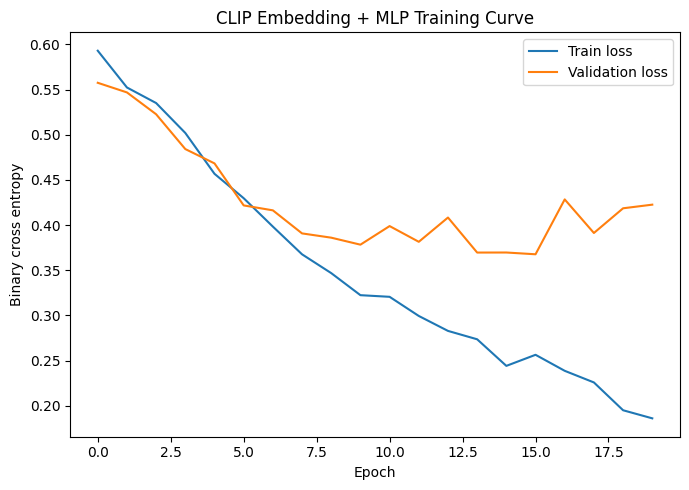

Saved: /content/drive/MyDrive/242B_negbench_outputs/mlp_loss_curve.png


In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross entropy")
plt.title("CLIP Embedding + MLP Training Curve")
plt.legend()
plt.tight_layout()

loss_path = os.path.join(OUTPUT_DIR, "mlp_loss_curve.png")
plt.savefig(loss_path, dpi=200)
plt.show()

print("Saved:", loss_path)

## New experiment

In [ ]:
# ============================================================
# Evaluation Helper Functions
# Put this BEFORE Stage 1 / Stage 2 / Stage 3 evaluation
# ============================================================

@torch.no_grad()
def predict_mlp_scores(model, X, batch_size=256, use_sigmoid=False):
    """
    Predict pair-level scores.

    use_sigmoid=False:
        Return raw logits. Recommended for comparing Stage 1, Stage 2, Stage 3 margins.

    use_sigmoid=True:
        Return sigmoid probabilities.
    """
    model.eval()

    loader = DataLoader(
        torch.tensor(X, dtype=torch.float32),
        batch_size=batch_size,
        shuffle=False
    )

    scores = []

    for xb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)

        if use_sigmoid:
            out = torch.sigmoid(logits)
        else:
            out = logits

        scores.extend(out.detach().cpu().numpy().tolist())

    return np.array(scores)


def mcq_eval_from_pair_scores(pair_rows, scores):
    df = pd.DataFrame(pair_rows).copy()
    df["score"] = scores

    preds = []
    labels = []
    margins = []
    failure_rows = []

    for ex_id, g in df.groupby("ex_id"):
        g = g.sort_values("option_idx").reset_index(drop=True)

        score_arr = g["score"].values
        pred_idx = int(np.argmax(score_arr))
        correct_idx = int(g["correct_idx"].iloc[0])

        correct_score = float(score_arr[correct_idx])
        wrong_scores = [
            float(score_arr[j])
            for j in range(len(score_arr))
            if j != correct_idx
        ]

        max_wrong_score = max(wrong_scores)
        margin = correct_score - max_wrong_score

        preds.append(pred_idx)
        labels.append(correct_idx)
        margins.append(margin)

        if pred_idx != correct_idx:
            options = g["all_options"].iloc[0]
            image_path = g["image_path"].iloc[0]

            failure_rows.append({
                "ex_id": ex_id,
                "image_path": image_path,
                "correct_idx": correct_idx,
                "pred_idx": pred_idx,
                "correct_caption": options[correct_idx],
                "pred_caption": options[pred_idx],
                "margin": margin,
                "scores": score_arr.tolist()
            })

    acc = float(np.mean([p == y for p, y in zip(preds, labels)]))
    mean_margin = float(np.mean(margins))
    positive_margin_ratio = float(np.mean([m > 0 for m in margins]))

    return {
        "accuracy": acc,
        "mean_margin": mean_margin,
        "positive_margin_ratio": positive_margin_ratio,
        "preds": preds,
        "labels": labels,
        "margins": margins,
        "failures": failure_rows
    }

print("Evaluation helpers loaded.")

Evaluation helpers loaded.


In [ ]:
# ============================================================
# Stage 1 / Stage 2 Feature Preparation
# ============================================================
# Your current X_train/X_val/X_test already contains:
# [image_emb, text_emb, abs(image_emb - text_emb), image_emb * text_emb]
# Therefore:
#   Stage 1 = concat only: [image_emb, text_emb]
#   Stage 2 = interaction features: full X

EMB_DIM = X_train.shape[1] // 4
print("Detected CLIP embedding dim:", EMB_DIM)

# Stage 1: concat-only features
X_train_concat = X_train[:, :2 * EMB_DIM]
X_val_concat   = X_val[:, :2 * EMB_DIM]
X_test_concat  = X_test[:, :2 * EMB_DIM]

# Stage 2: interaction features
X_train_inter = X_train
X_val_inter   = X_val
X_test_inter  = X_test

print("Stage 1 concat feature dim:", X_train_concat.shape[1])
print("Stage 2 interaction feature dim:", X_train_inter.shape[1])

Detected CLIP embedding dim: 512
Stage 1 concat feature dim: 1024
Stage 2 interaction feature dim: 2048


In [ ]:
# ============================================================
# Stage 1: Frozen CLIP + concat-only MLP
# ============================================================
stage1_model, stage1_history = train_mlp(
    X_train_concat, y_train,
    X_val_concat, y_val,
    epochs=20,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=4
)

stage1_scores = predict_mlp_scores(
    stage1_model,
    X_test_concat,
    use_sigmoid=False
)
stage1_test = mcq_eval_from_pair_scores(test_pairs, stage1_scores)

print("\nStage 1: Frozen CLIP + concat-only MLP")
print("Accuracy:", stage1_test["accuracy"])
print("Mean confidence margin:", stage1_test["mean_margin"])
print("Positive margin ratio:", stage1_test["positive_margin_ratio"])
print("Failures:", len(stage1_test["failures"]))


# ============================================================
# Stage 2: Frozen CLIP + interaction-feature MLP
# ============================================================
stage2_model, stage2_history = train_mlp(
    X_train_inter, y_train,
    X_val_inter, y_val,
    epochs=20,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=4
)

stage2_scores = predict_mlp_scores(
    stage2_model,
    X_test_inter,
    use_sigmoid=False
)
stage2_test = mcq_eval_from_pair_scores(test_pairs, stage2_scores)

print("\nStage 2: Frozen CLIP + interaction-feature MLP")
print("Accuracy:", stage2_test["accuracy"])
print("Mean confidence margin:", stage2_test["mean_margin"])
print("Positive margin ratio:", stage2_test["positive_margin_ratio"])
print("Failures:", len(stage2_test["failures"]))

Epoch 01 | train_loss=0.6136 val_loss=0.5544 | train_acc=0.7151 val_acc=0.7500
Epoch 02 | train_loss=0.5506 val_loss=0.5404 | train_acc=0.7500 val_acc=0.7500
Epoch 03 | train_loss=0.5258 val_loss=0.5150 | train_acc=0.7500 val_acc=0.7531
Epoch 04 | train_loss=0.4956 val_loss=0.4931 | train_acc=0.7812 val_acc=0.8109
Epoch 05 | train_loss=0.4611 val_loss=0.4492 | train_acc=0.8073 val_acc=0.8141
Epoch 06 | train_loss=0.4203 val_loss=0.4165 | train_acc=0.8281 val_acc=0.8234
Epoch 07 | train_loss=0.3945 val_loss=0.3903 | train_acc=0.8323 val_acc=0.8391
Epoch 08 | train_loss=0.3609 val_loss=0.3814 | train_acc=0.8526 val_acc=0.8438
Epoch 09 | train_loss=0.3368 val_loss=0.3658 | train_acc=0.8625 val_acc=0.8375
Epoch 10 | train_loss=0.3172 val_loss=0.3660 | train_acc=0.8734 val_acc=0.8438
Epoch 11 | train_loss=0.2960 val_loss=0.3579 | train_acc=0.8797 val_acc=0.8484
Epoch 12 | train_loss=0.2746 val_loss=0.3711 | train_acc=0.8948 val_acc=0.8453
Epoch 13 | train_loss=0.2615 val_loss=0.3538 | train

In [ ]:
# ============================================================
# Stage 4: Listwise MCQ Training with Concat Features
# ============================================================

import copy
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


class MCQFeatureDataset(Dataset):
    """
    MCQ-level dataset.
    Each sample contains all candidate caption features for one image.
    """
    def __init__(self, X_pairs, pair_rows):
        self.examples = []

        df_meta = pd.DataFrame(pair_rows).copy()
        df_meta["pair_position"] = np.arange(len(pair_rows))

        for ex_id, g in df_meta.groupby("ex_id"):
            g = g.sort_values("option_idx")

            indices = g["pair_position"].values
            X_ex = X_pairs[indices]
            correct_idx = int(g["correct_idx"].iloc[0])

            self.examples.append({
                "X": torch.tensor(X_ex, dtype=torch.float32),
                "y": correct_idx
            })

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]["X"], self.examples[idx]["y"]


def mcq_collate_fn(batch):
    X_list, y_list = zip(*batch)

    batch_size = len(X_list)
    max_k = max(x.shape[0] for x in X_list)
    dim = X_list[0].shape[1]

    X_pad = torch.zeros(batch_size, max_k, dim, dtype=torch.float32)
    mask = torch.zeros(batch_size, max_k, dtype=torch.bool)

    for i, x in enumerate(X_list):
        k = x.shape[0]
        X_pad[i, :k] = x
        mask[i, :k] = True

    y = torch.tensor(y_list, dtype=torch.long)
    return X_pad, y, mask


def train_listwise_mlp(
    X_train,
    train_pairs,
    X_val,
    val_pairs,
    hidden_dim=128,
    dropout=0.35,
    epochs=30,
    batch_size=32,
    lr=5e-4,
    weight_decay=1e-4,
    patience=5
):
    train_ds = MCQFeatureDataset(X_train, train_pairs)
    val_ds = MCQFeatureDataset(X_val, val_pairs)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=mcq_collate_fn
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=mcq_collate_fn
    )

    model = MLPMatcher(
        input_dim=X_train.shape[1],
        hidden_dim=hidden_dim,
        dropout=dropout
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_accs = []

        for xb, yb, mask in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            mask = mask.to(DEVICE)

            B, K, D = xb.shape

            optimizer.zero_grad()

            flat_x = xb.view(B * K, D)
            flat_scores = model(flat_x)
            scores = flat_scores.view(B, K)

            masked_scores = scores.masked_fill(~mask, -1e9)

            loss = F.cross_entropy(masked_scores, yb)

            loss.backward()
            optimizer.step()

            preds = masked_scores.argmax(dim=1)
            acc = (preds == yb).float().mean().item()

            train_losses.append(loss.item())
            train_accs.append(acc)

        model.eval()
        val_losses = []
        val_accs = []

        with torch.no_grad():
            for xb, yb, mask in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                mask = mask.to(DEVICE)

                B, K, D = xb.shape

                flat_x = xb.view(B * K, D)
                flat_scores = model(flat_x)
                scores = flat_scores.view(B, K)

                masked_scores = scores.masked_fill(~mask, -1e9)

                loss = F.cross_entropy(masked_scores, yb)

                preds = masked_scores.argmax(dim=1)
                acc = (preds == yb).float().mean().item()

                val_losses.append(loss.item())
                val_accs.append(acc)

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        train_acc = float(np.mean(train_accs))
        val_acc = float(np.mean(val_accs))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [ ]:
# ============================================================
# Train Stage 3: Listwise MCQ-trained Concat MLP
# ============================================================

stage3_model, stage3_history = train_listwise_mlp(
    X_train_concat,
    train_pairs,
    X_val_concat,
    val_pairs,
    hidden_dim=128,
    dropout=0.35,
    epochs=30,
    batch_size=32,
    lr=5e-4,
    weight_decay=1e-4,
    patience=5
)

stage3_scores = predict_mlp_scores(
    stage3_model,
    X_test_concat,
    use_sigmoid=False
)

stage3_test = mcq_eval_from_pair_scores(test_pairs, stage3_scores)

print("\nStage 3: Listwise MCQ-trained concat MLP")
print("Accuracy:", stage3_test["accuracy"])
print("Mean confidence margin:", stage3_test["mean_margin"])
print("Positive margin ratio:", stage3_test["positive_margin_ratio"])
print("Failures:", len(stage3_test["failures"]))

Epoch 01 | train_loss=1.3844 val_loss=1.3830 | train_acc=0.3125 val_acc=0.5375
Epoch 02 | train_loss=1.3793 val_loss=1.3757 | train_acc=0.3667 val_acc=0.5312
Epoch 03 | train_loss=1.3651 val_loss=1.3588 | train_acc=0.5458 val_acc=0.5437
Epoch 04 | train_loss=1.3385 val_loss=1.3267 | train_acc=0.5250 val_acc=0.5437
Epoch 05 | train_loss=1.2877 val_loss=1.2714 | train_acc=0.5563 val_acc=0.5437
Epoch 06 | train_loss=1.2176 val_loss=1.1939 | train_acc=0.5625 val_acc=0.5437
Epoch 07 | train_loss=1.1208 val_loss=1.1070 | train_acc=0.5687 val_acc=0.5625
Epoch 08 | train_loss=1.0294 val_loss=1.0319 | train_acc=0.5729 val_acc=0.5813
Epoch 09 | train_loss=0.9473 val_loss=0.9683 | train_acc=0.6208 val_acc=0.5938
Epoch 10 | train_loss=0.9084 val_loss=0.9208 | train_acc=0.6250 val_acc=0.6062
Epoch 11 | train_loss=0.8532 val_loss=0.8765 | train_acc=0.6375 val_acc=0.6687
Epoch 12 | train_loss=0.7821 val_loss=0.8331 | train_acc=0.6979 val_acc=0.7125
Epoch 13 | train_loss=0.7473 val_loss=0.8101 | train

In [ ]:
[name for name in globals().keys() if "clip" in name.lower() and "score" in name.lower()]

['clip_score_options']

In [ ]:
# ============================================================
# Compute CLIP pair-level cosine scores from existing features
# ============================================================

def clip_cosine_scores_from_features(X):
    """
    X is assumed to contain:
    [image_emb, text_emb, abs(image_emb - text_emb), image_emb * text_emb]

    Returns cosine similarity score for each image-caption pair.
    """
    emb_dim = X.shape[1] // 4

    img_emb = X[:, :emb_dim]
    txt_emb = X[:, emb_dim:2 * emb_dim]

    img_norm = img_emb / (np.linalg.norm(img_emb, axis=1, keepdims=True) + 1e-8)
    txt_norm = txt_emb / (np.linalg.norm(txt_emb, axis=1, keepdims=True) + 1e-8)

    scores = np.sum(img_norm * txt_norm, axis=1)
    return scores


clip_val_scores = clip_cosine_scores_from_features(X_val_inter)
clip_test_scores = clip_cosine_scores_from_features(X_test_inter)

print("clip_val_scores:", clip_val_scores.shape)
print("clip_test_scores:", clip_test_scores.shape)

clip_val_scores: (640,)
clip_test_scores: (640,)


In [ ]:
# ============================================================
# Helper: Per-example score normalization
# ============================================================

def normalize_scores_by_example(pair_rows, scores):
    """
    Normalize scores within each MCQ example.

    This avoids scale mismatch between CLIP cosine scores and MLP logits.
    """
    df = pd.DataFrame(pair_rows).copy()
    df["score"] = scores

    norm_scores = np.zeros_like(scores, dtype=float)

    for ex_id, g in df.groupby("ex_id"):
        idx = g.index.values
        s = df.loc[idx, "score"].values.astype(float)

        mean = s.mean()
        std = s.std()

        if std < 1e-8:
            norm_s = s - mean
        else:
            norm_s = (s - mean) / std

        norm_scores[idx] = norm_s

    return norm_scores

In [ ]:
# ============================================================
# Stage 4: Validation-tuned Ensemble
# CLIP cosine + Stage 1 Pairwise Concat MLP
# ============================================================

# Stage 1 MLP raw-logit scores
stage1_val_scores = predict_mlp_scores(
    stage1_model,
    X_val_concat,
    use_sigmoid=False
)

stage1_test_scores = predict_mlp_scores(
    stage1_model,
    X_test_concat,
    use_sigmoid=False
)

# Normalize scores within each MCQ group
stage1_val_norm = normalize_scores_by_example(val_pairs, stage1_val_scores)
stage1_test_norm = normalize_scores_by_example(test_pairs, stage1_test_scores)

clip_val_norm = normalize_scores_by_example(val_pairs, clip_val_scores)
clip_test_norm = normalize_scores_by_example(test_pairs, clip_test_scores)

# Search alpha on validation set
alphas = np.linspace(0, 1, 21)

ensemble_val_rows = []

best_alpha = None
best_val_acc = -1
best_val_result = None

for alpha in alphas:
    val_ens_scores = alpha * stage1_val_norm + (1 - alpha) * clip_val_norm
    val_result = mcq_eval_from_pair_scores(val_pairs, val_ens_scores)

    ensemble_val_rows.append({
        "alpha": alpha,
        "val_accuracy": val_result["accuracy"],
        "val_mean_margin": val_result["mean_margin"],
        "val_positive_margin_ratio": val_result["positive_margin_ratio"],
        "val_num_failures": len(val_result["failures"])
    })

    if val_result["accuracy"] > best_val_acc:
        best_val_acc = val_result["accuracy"]
        best_alpha = alpha
        best_val_result = val_result

ensemble_val_df = pd.DataFrame(ensemble_val_rows)
display(ensemble_val_df)

print("Best alpha selected on validation:", best_alpha)
print("Best validation accuracy:", best_val_acc)

# Evaluate on test with fixed validation-selected alpha
stage4_scores = best_alpha * stage1_test_norm + (1 - best_alpha) * clip_test_norm
stage4_test = mcq_eval_from_pair_scores(test_pairs, stage4_scores)

print("\nStage 4: Validation-tuned CLIP + Stage 1 MLP Ensemble")
print("Best alpha:", best_alpha)
print("Accuracy:", stage4_test["accuracy"])
print("Mean confidence margin:", stage4_test["mean_margin"])
print("Positive margin ratio:", stage4_test["positive_margin_ratio"])
print("Failures:", len(stage4_test["failures"]))

# Save validation search results
ensemble_val_path = os.path.join(OUTPUT_DIR, "ensemble_alpha_validation_search.csv")
ensemble_val_df.to_csv(ensemble_val_path, index=False)
print("Saved:", ensemble_val_path)

,alpha,val_accuracy,val_mean_margin,val_positive_margin_ratio,val_num_failures
0,0.00,0.43750,-0.422699,0.43750,90
1,0.05,0.45000,-0.330972,0.45000,88
2,0.10,0.45625,-0.241195,0.45625,87
3,0.15,0.46875,-0.152926,0.46875,85
4,0.20,0.50000,-0.066928,0.50000,80
5,0.25,0.51250,0.017606,0.51250,78
6,0.30,0.52500,0.098615,0.52500,76
7,0.35,0.54375,0.176719,0.54375,73
8,0.40,0.55000,0.253203,0.55000,72
9,0.45,0.56250,0.326572,0.56250,70


Best alpha selected on validation: 0.8
Best validation accuracy: 0.7625

Stage 4: Validation-tuned CLIP + Stage 1 MLP Ensemble
Best alpha: 0.8
Accuracy: 0.73125
Mean confidence margin: 0.6498031524227594
Positive margin ratio: 0.73125
Failures: 43
Saved: /content/drive/MyDrive/242B_negbench_outputs/ensemble_alpha_validation_search.csv


In [ ]:
# ============================================================
# Stage 5: Object-Aware Negation Verifier
# Load pretrained COCO object detector
# ============================================================

import os
import re
import json
import ast
from PIL import Image

import torch
import torchvision
from torchvision.transforms import functional as TF
import numpy as np
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Faster R-CNN pretrained on COCO
try:
    from torchvision.models.detection import fasterrcnn_resnet50_fpn
    from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    detector = fasterrcnn_resnet50_fpn(weights=weights)
    COCO_CATEGORIES = weights.meta["categories"]

except Exception as e:
    print("Torchvision weights API failed, falling back to legacy pretrained=True.")
    print("Error:", e)

    detector = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    COCO_CATEGORIES = [
        "__background__", "person", "bicycle", "car", "motorcycle", "airplane", "bus",
        "train", "truck", "boat", "traffic light", "fire hydrant", "stop sign",
        "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
        "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag",
        "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite",
        "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket",
        "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana",
        "apple", "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
        "donut", "cake", "chair", "couch", "potted plant", "bed", "dining table",
        "toilet", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
        "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock",
        "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
    ]

detector = detector.to(DEVICE)
detector.eval()

print("Detector loaded.")
print("Number of COCO categories:", len(COCO_CATEGORIES))
print(COCO_CATEGORIES[:10])

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 342MB/s]


Detector loaded.
Number of COCO categories: 91
['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']


In [ ]:
# ============================================================
# Caption object-claim parser
# ============================================================

# COCO object names excluding background-like entries
COCO_OBJECTS = [
    c.lower()
    for c in COCO_CATEGORIES
    if c.lower() not in ["__background__", "n/a"]
]

# Some common aliases appearing in captions
OBJECT_ALIASES = {
    "tv": ["tv", "television", "tv monitor"],
    "couch": ["couch", "sofa"],
    "cell phone": ["cell phone", "phone", "mobile phone"],
    "dining table": ["dining table", "table"],
    "potted plant": ["potted plant", "plant"],
    "airplane": ["airplane", "plane"],
    "motorcycle": ["motorcycle", "motorbike"],
    "bicycle": ["bicycle", "bike"],
}

# Add default self-aliases
for obj in COCO_OBJECTS:
    OBJECT_ALIASES.setdefault(obj, [obj])

NEGATION_PATTERNS = [
    r"\bno\b",
    r"\bnot\b",
    r"\bwithout\b",
    r"\babsent\b",
    r"\bmissing\b",
    r"\bnot present\b",
    r"\bnot included\b",
    r"\bnot visible\b",
    r"\bnoticeably absent\b",
    r"\bthere is no\b",
    r"\bthere are no\b",
]

PRESENT_PATTERNS = [
    r"\bpresent\b",
    r"\bincluded\b",
    r"\bvisible\b",
    r"\bshown\b",
    r"\bshows\b",
    r"\bfeatures\b",
    r"\bcontains\b",
    r"\bthere is\b",
    r"\bthere are\b",
]


def normalize_caption_text(text):
    text = str(text).lower()
    text = text.replace("there’s", "there is")
    text = text.replace("there're", "there are")
    text = text.replace("there isn't", "there is not")
    text = text.replace("there aren't", "there are not")
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def object_regex(alias):
    """
    Match singular or simple plural form.
    Example:
        bottle -> bottle/bottles
        dining table -> dining table/dining tables
    """
    alias = re.escape(alias.lower())
    if alias.endswith("s"):
        return rf"\b{alias}\b"
    return rf"\b{alias}s?\b"


def context_has_negation(context):
    return any(re.search(p, context) for p in NEGATION_PATTERNS)


def context_has_presence(context):
    return any(re.search(p, context) for p in PRESENT_PATTERNS)


def extract_object_claims(caption, window_tokens=7):
    """
    Extract object-level presence/absence claims from a caption.

    Returns:
        list of (canonical_object_name, relation)
        relation in {"present", "absent"}
    """
    text = normalize_caption_text(caption)
    tokens = text.split()

    claims = []

    for obj, aliases in OBJECT_ALIASES.items():
        found_positions = []

        for alias in aliases:
            pattern = object_regex(alias)
            for m in re.finditer(pattern, text):
                # approximate token position
                prefix = text[:m.start()]
                pos = len(prefix.split())
                found_positions.append(pos)

        if not found_positions:
            continue

        # Use each object once
        pos = min(found_positions)

        left = max(0, pos - window_tokens)
        right = min(len(tokens), pos + window_tokens + 1)
        context = " ".join(tokens[left:right])

        # Also inspect the whole sentence for patterns like:
        # "No bottle is included in this image."
        relation = "present"

        if context_has_negation(context):
            relation = "absent"
        else:
            # Special pattern: "no <object>"
            for alias in aliases:
                if re.search(rf"\bno\s+{object_regex(alias).replace(r'\b', '')}", text):
                    relation = "absent"

        claims.append((obj, relation))

    # Deduplicate, prioritize absent if same object appears both ways
    claim_dict = {}
    for obj, rel in claims:
        if obj not in claim_dict:
            claim_dict[obj] = rel
        elif rel == "absent":
            claim_dict[obj] = "absent"

    return list(claim_dict.items())


# Quick sanity checks
test_captions = [
    "A handbag is not present in this image.",
    "A dog is present in this image, but no person is visible.",
    "This image features a chair and a dining table.",
    "This image shows a wine glass, but there's no bowl.",
    "A person is included in this image, but there is no dog."
]

for cap in test_captions:
    print(cap)
    print(extract_object_claims(cap))
    print()

A handbag is not present in this image.
[('handbag', 'absent')]

A dog is present in this image, but no person is visible.
[('person', 'absent'), ('dog', 'absent')]

This image features a chair and a dining table.
[('dining table', 'present'), ('chair', 'present')]

This image shows a wine glass, but there's no bowl.
[('wine glass', 'absent'), ('bowl', 'absent')]

A person is included in this image, but there is no dog.
[('person', 'present'), ('dog', 'absent')]



In [ ]:
# ============================================================
# Detect COCO objects in validation and test images
# ============================================================

def detect_objects_in_image(image_path, score_threshold=0.45):
    """
    Return detected COCO object set for one image.
    """
    img = Image.open(image_path).convert("RGB")
    x = TF.to_tensor(img).to(DEVICE)

    with torch.no_grad():
        output = detector([x])[0]

    labels = output["labels"].detach().cpu().numpy()
    scores = output["scores"].detach().cpu().numpy()

    detected = set()

    for label, score in zip(labels, scores):
        if score < score_threshold:
            continue

        label = int(label)

        if 0 <= label < len(COCO_CATEGORIES):
            obj_name = COCO_CATEGORIES[label].lower()
            if obj_name not in ["__background__", "n/a"]:
                detected.add(obj_name)

    return detected


def get_unique_image_paths(pair_rows):
    df = pd.DataFrame(pair_rows)
    return sorted(df["image_path"].unique().tolist())


cache_path = os.path.join(OUTPUT_DIR, "object_detector_cache_val_test.json")

if os.path.exists(cache_path):
    with open(cache_path, "r") as f:
        object_cache_raw = json.load(f)

    object_cache = {
        path: set(objs)
        for path, objs in object_cache_raw.items()
    }

    print("Loaded object detector cache:", cache_path)
    print("Cached images:", len(object_cache))

else:
    object_cache = {}

    unique_paths = sorted(
        set(get_unique_image_paths(val_pairs)) |
        set(get_unique_image_paths(test_pairs))
    )

    print("Running detector on unique images:", len(unique_paths))

    for idx, image_path in enumerate(unique_paths):
        if idx % 20 == 0:
            print(f"Detecting {idx}/{len(unique_paths)}")

        try:
            object_cache[image_path] = detect_objects_in_image(
                image_path,
                score_threshold=0.45
            )
        except Exception as e:
            print("Detection failed:", image_path)
            print(e)
            object_cache[image_path] = set()

    object_cache_raw = {
        path: sorted(list(objs))
        for path, objs in object_cache.items()
    }

    with open(cache_path, "w") as f:
        json.dump(object_cache_raw, f, indent=2)

    print("Saved object detector cache:", cache_path)

# Show example
sample_path = list(object_cache.keys())[0]
print("Example image:", sample_path)
print("Detected objects:", object_cache[sample_path])

Running detector on unique images: 274
Detecting 0/274
Detecting 20/274
Detecting 40/274
Detecting 60/274
Detecting 80/274
Detecting 100/274
Detecting 120/274
Detecting 140/274
Detecting 160/274
Detecting 180/274
Detecting 200/274
Detecting 220/274
Detecting 240/274
Detecting 260/274
Saved object detector cache: /content/drive/MyDrive/242B_negbench_outputs/object_detector_cache_val_test.json
Example image: /content/drive/MyDrive/242B/FinalProject/data/coco/val2017/000000000724.jpg
Detected objects: {'truck', 'stop sign'}


In [ ]:
# ============================================================
# Object-aware verification score
# ============================================================

def get_caption_from_pair_row(row):
    """
    Robustly extract candidate caption from a pair row.
    """
    possible_keys = [
        "caption",
        "text",
        "option",
        "candidate_caption",
        "option_caption"
    ]

    for k in possible_keys:
        if k in row and isinstance(row[k], str):
            return row[k]

    if "all_options" in row and "option_idx" in row:
        options = row["all_options"]

        if isinstance(options, str):
            try:
                options = ast.literal_eval(options)
            except Exception:
                pass

        if isinstance(options, (list, tuple)):
            return options[int(row["option_idx"])]

    raise ValueError(f"Cannot find caption in row keys: {row.keys()}")


def object_verification_score_for_caption(caption, detected_objects):
    claims = extract_object_claims(caption)

    if len(claims) == 0:
        return 0.0

    score = 0.0

    for obj, relation in claims:
        detected = obj in detected_objects

        # Handle aliases at detection side too
        aliases = OBJECT_ALIASES.get(obj, [obj])
        detected = detected or any(alias in detected_objects for alias in aliases)

        if relation == "present":
            score += 1.0 if detected else -1.0
        elif relation == "absent":
            score += 1.0 if not detected else -1.0

    # Normalize by number of claims to avoid favoring longer captions
    score = score / len(claims)
    return float(score)


def compute_object_scores(pair_rows, object_cache):
    scores = []

    for row in pair_rows:
        image_path = row["image_path"]
        caption = get_caption_from_pair_row(row)
        detected_objects = object_cache.get(image_path, set())

        s_obj = object_verification_score_for_caption(
            caption,
            detected_objects
        )
        scores.append(s_obj)

    return np.array(scores, dtype=float)


obj_val_scores = compute_object_scores(val_pairs, object_cache)
obj_test_scores = compute_object_scores(test_pairs, object_cache)

print("obj_val_scores:", obj_val_scores.shape, obj_val_scores.min(), obj_val_scores.max())
print("obj_test_scores:", obj_test_scores.shape, obj_test_scores.min(), obj_test_scores.max())

# Direct object-only performance
obj_val_test = mcq_eval_from_pair_scores(val_pairs, obj_val_scores)
obj_test = mcq_eval_from_pair_scores(test_pairs, obj_test_scores)

print("\nObject-only verifier")
print("Validation accuracy:", obj_val_test["accuracy"])
print("Test accuracy:", obj_test["accuracy"])
print("Test mean margin:", obj_test["mean_margin"])
print("Test failures:", len(obj_test["failures"]))

obj_val_scores: (640,) -1.0 1.0
obj_test_scores: (640,) -1.0 1.0

Object-only verifier
Validation accuracy: 0.86875
Test accuracy: 0.8
Test mean margin: 0.34375
Test failures: 32


In [ ]:
# ============================================================
# Stage 5: Stage 1 MLP + Object-Aware Negation Verifier
# ============================================================

# Stage 1 raw-logit scores
stage1_val_scores = predict_mlp_scores(
    stage1_model,
    X_val_concat,
    use_sigmoid=False
)

stage1_test_scores = predict_mlp_scores(
    stage1_model,
    X_test_concat,
    use_sigmoid=False
)

# Normalize scores within each MCQ group
stage1_val_norm = normalize_scores_by_example(val_pairs, stage1_val_scores)
stage1_test_norm = normalize_scores_by_example(test_pairs, stage1_test_scores)

obj_val_norm = normalize_scores_by_example(val_pairs, obj_val_scores)
obj_test_norm = normalize_scores_by_example(test_pairs, obj_test_scores)

# Search beta on validation set
betas = np.linspace(-1.0, 3.0, 41)

stage5_val_rows = []

best_beta = None
best_val_acc = -1
best_val_margin = -1
best_val_result = None

for beta in betas:
    val_scores = stage1_val_norm + beta * obj_val_norm
    val_result = mcq_eval_from_pair_scores(val_pairs, val_scores)

    row = {
        "beta": beta,
        "val_accuracy": val_result["accuracy"],
        "val_mean_margin": val_result["mean_margin"],
        "val_positive_margin_ratio": val_result["positive_margin_ratio"],
        "val_num_failures": len(val_result["failures"])
    }
    stage5_val_rows.append(row)

    # Primary selection: validation accuracy
    # Tie-breaker: validation mean margin
    if (
        val_result["accuracy"] > best_val_acc
        or (
            val_result["accuracy"] == best_val_acc
            and val_result["mean_margin"] > best_val_margin
        )
    ):
        best_beta = beta
        best_val_acc = val_result["accuracy"]
        best_val_margin = val_result["mean_margin"]
        best_val_result = val_result

stage5_val_df = pd.DataFrame(stage5_val_rows)
display(stage5_val_df)

print("Best beta selected on validation:", best_beta)
print("Best validation accuracy:", best_val_acc)
print("Best validation mean margin:", best_val_margin)

# Evaluate on test
stage5_scores = stage1_test_norm + best_beta * obj_test_norm
stage5_test = mcq_eval_from_pair_scores(test_pairs, stage5_scores)

print("\nStage 5: Stage 1 MLP + Object-Aware Negation Verifier")
print("Best beta:", best_beta)
print("Accuracy:", stage5_test["accuracy"])
print("Mean confidence margin:", stage5_test["mean_margin"])
print("Positive margin ratio:", stage5_test["positive_margin_ratio"])
print("Failures:", len(stage5_test["failures"]))

# Save beta search
stage5_val_path = os.path.join(OUTPUT_DIR, "stage5_object_verifier_beta_search.csv")
stage5_val_df.to_csv(stage5_val_path, index=False)
print("Saved:", stage5_val_path)

,beta,val_accuracy,val_mean_margin,val_positive_margin_ratio,val_num_failures
0,-1.0,0.27500,-0.731240,0.27500,116
1,-0.9,0.36875,-0.540407,0.36875,101
2,-0.8,0.45000,-0.356953,0.45000,88
3,-0.7,0.59375,-0.178034,0.59375,65
4,-0.6,0.63125,-0.005029,0.63125,59
5,-0.5,0.68750,0.163883,0.68750,50
6,-0.4,0.71250,0.324384,0.71250,46
7,-0.3,0.73125,0.477015,0.73125,43
8,-0.2,0.74375,0.621141,0.74375,41
9,-0.1,0.75625,0.753680,0.75625,39


Best beta selected on validation: 0.9000000000000001
Best validation accuracy: 0.84375
Best validation mean margin: 1.562118921753343

Stage 5: Stage 1 MLP + Object-Aware Negation Verifier
Best beta: 0.9000000000000001
Accuracy: 0.8375
Mean confidence margin: 1.495314084635104
Positive margin ratio: 0.8375
Failures: 26
Saved: /content/drive/MyDrive/242B_negbench_outputs/stage5_object_verifier_beta_search.csv


In [ ]:
# ============================================================
# Ablation Results Table
# ============================================================

ablation_results = []

ablation_results.append({
    "model": "CLIP dual-encoder",
    "test_samples": len(test_records),
    "accuracy": clip_test["accuracy"],
    "mean_confidence_margin": clip_test["mean_margin"],
    "positive_margin_ratio": np.mean(np.array(clip_test["margins"]) > 0),
    "num_failures": len(clip_test["failures"])
})

if RUN_BLIP:
    ablation_results.append({
        "model": "BLIP-ITM cross-encoder",
        "test_samples": len(blip_test_records),
        "accuracy": blip_test["accuracy"],
        "mean_confidence_margin": blip_test["mean_margin"],
        "positive_margin_ratio": np.mean(np.array(blip_test["margins"]) > 0),
        "num_failures": len(blip_test["failures"])
    })

ablation_results.append({
    "model": "Stage 1: Pairwise concat MLP",
    "test_samples": len(test_records),
    "accuracy": stage1_test["accuracy"],
    "mean_confidence_margin": stage1_test["mean_margin"],
    "positive_margin_ratio": stage1_test["positive_margin_ratio"],
    "num_failures": len(stage1_test["failures"])
})

ablation_results.append({
    "model": "Stage 2: Pairwise interaction MLP",
    "test_samples": len(test_records),
    "accuracy": stage2_test["accuracy"],
    "mean_confidence_margin": stage2_test["mean_margin"],
    "positive_margin_ratio": stage2_test["positive_margin_ratio"],
    "num_failures": len(stage2_test["failures"])
})

ablation_results.append({
    "model": "Stage 3: Listwise concat MLP",
    "test_samples": len(test_records),
    "accuracy": stage3_test["accuracy"],
    "mean_confidence_margin": stage3_test["mean_margin"],
    "positive_margin_ratio": stage3_test["positive_margin_ratio"],
    "num_failures": len(stage3_test["failures"])
})

ablation_results.append({
    "model": "Stage 4: CLIP + Stage 1 ensemble",
    "test_samples": len(test_records),
    "accuracy": stage4_test["accuracy"],
    "mean_confidence_margin": stage4_test["mean_margin"],
    "positive_margin_ratio": stage4_test["positive_margin_ratio"],
    "num_failures": len(stage4_test["failures"])
})

ablation_results.append({
    "model": "Stage 5: MLP + object verifier",
    "test_samples": len(test_records),
    "accuracy": stage5_test["accuracy"],
    "mean_confidence_margin": stage5_test["mean_margin"],
    "positive_margin_ratio": stage5_test["positive_margin_ratio"],
    "num_failures": len(stage5_test["failures"])
})

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

ablation_path = os.path.join(OUTPUT_DIR, "ablation_results_final.csv")
ablation_df.to_csv(ablation_path, index=False)

print("Saved:", ablation_path)

,model,test_samples,accuracy,mean_confidence_margin,positive_margin_ratio,num_failures
0,CLIP dual-encoder,160,0.41250,-0.005324,0.41250,94
1,BLIP-ITM cross-encoder,160,0.22500,-0.031439,0.22500,124
2,Stage 1: Pairwise concat MLP,160,0.74375,3.117979,0.74375,41
3,Stage 2: Pairwise interaction MLP,160,0.71875,2.166710,0.71875,45
4,Stage 3: Listwise concat MLP,160,0.74375,2.375558,0.74375,41
5,Stage 4: CLIP + Stage 1 ensemble,160,0.73125,0.649803,0.73125,43
6,Stage 5: MLP + object verifier,160,0.83750,1.495314,0.83750,26


Saved: /content/drive/MyDrive/242B_negbench_outputs/ablation_results_final.csv


In [ ]:
# ============================================================
# McNemar Test with Stage 5
# ============================================================

mcnemar_results = []

mcnemar_results.append(
    mcnemar_compare(
        stage1_test,
        stage5_test,
        name_a="Stage 1 concat MLP",
        name_b="Stage 5 object verifier"
    )
)

mcnemar_results.append(
    mcnemar_compare(
        stage3_test,
        stage5_test,
        name_a="Stage 3 listwise MLP",
        name_b="Stage 5 object verifier"
    )
)

mcnemar_df_stage5 = pd.DataFrame(mcnemar_results)
display(mcnemar_df_stage5)

mcnemar_stage5_path = os.path.join(OUTPUT_DIR, "mcnemar_stage5_tests.csv")
mcnemar_df_stage5.to_csv(mcnemar_stage5_path, index=False)
print("Saved:", mcnemar_stage5_path)


McNemar Test: Stage 1 concat MLP vs. Stage 5 object verifier
Contingency table:
                            Stage 5 object verifier correct  \
Stage 1 concat MLP correct                              112   
Stage 1 concat MLP wrong                                 22   

                            Stage 5 object verifier wrong  
Stage 1 concat MLP correct                              7  
Stage 1 concat MLP wrong                               19  
Statistic: 7.0
p-value: 0.008130058646202087

McNemar Test: Stage 3 listwise MLP vs. Stage 5 object verifier
Contingency table:
                              Stage 5 object verifier correct  \
Stage 3 listwise MLP correct                              110   
Stage 3 listwise MLP wrong                                 24   

                              Stage 5 object verifier wrong  
Stage 3 listwise MLP correct                              9  
Stage 3 listwise MLP wrong                               17  
Statistic: 9.0
p-value: 0.0135309868492

,model_a,model_b,both_correct,a_correct_b_wrong,a_wrong_b_correct,both_wrong,p_value
0,Stage 1 concat MLP,Stage 5 object verifier,112,7,22,19,0.008130
1,Stage 3 listwise MLP,Stage 5 object verifier,110,9,24,17,0.013531


Saved: /content/drive/MyDrive/242B_negbench_outputs/mcnemar_stage5_tests.csv


In [ ]:
# ============================================================
# Bootstrap CI with Stage 5
# ============================================================

ci_rows = []

model_results_for_ci = [
    ("CLIP dual-encoder", clip_test),
    ("Stage 1 concat MLP", stage1_test),
    ("Stage 2 interaction MLP", stage2_test),
    ("Stage 3 listwise MLP", stage3_test),
    ("Stage 4 ensemble", stage4_test),
    ("Stage 5 object verifier", stage5_test)
]

if RUN_BLIP:
    model_results_for_ci.insert(1, ("BLIP-ITM cross-encoder", blip_test))

for name, result in model_results_for_ci:
    acc, lo, hi = bootstrap_accuracy_ci(result)

    ci_rows.append({
        "model": name,
        "accuracy": acc,
        "ci_lower": lo,
        "ci_upper": hi
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)

ci_path = os.path.join(OUTPUT_DIR, "accuracy_bootstrap_ci_with_stage5.csv")
ci_df.to_csv(ci_path, index=False)
print("Saved:", ci_path)

,model,accuracy,ci_lower,ci_upper
0,CLIP dual-encoder,0.41250,0.3375,0.48750
1,BLIP-ITM cross-encoder,0.22500,0.1625,0.29375
2,Stage 1 concat MLP,0.74375,0.6750,0.80625
3,Stage 2 interaction MLP,0.71875,0.6500,0.78750
4,Stage 3 listwise MLP,0.74375,0.6750,0.80625
5,Stage 4 ensemble,0.73125,0.6625,0.80000
6,Stage 5 object verifier,0.83750,0.7750,0.89375


Saved: /content/drive/MyDrive/242B_negbench_outputs/accuracy_bootstrap_ci_with_stage5.csv


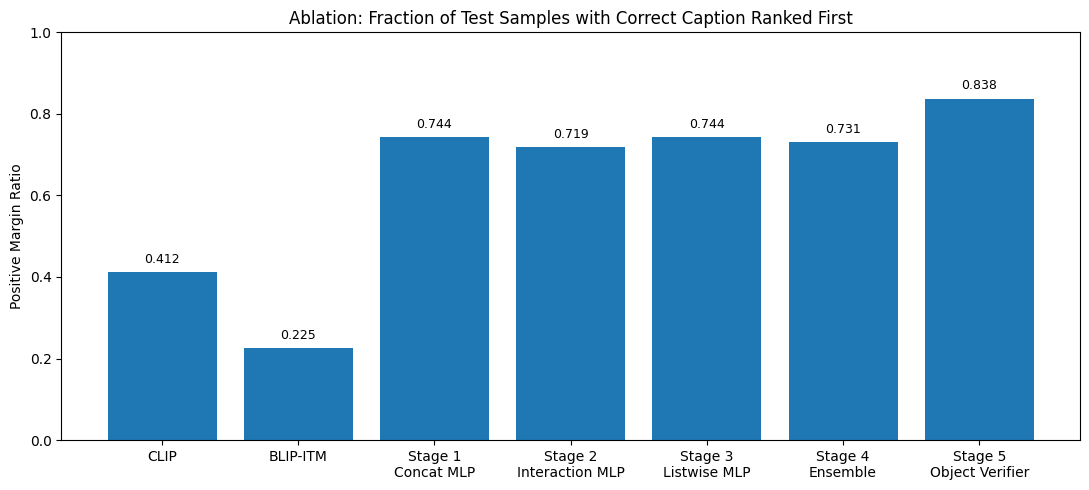

Saved: /content/drive/MyDrive/242B_negbench_outputs/ablation_positive_margin_ratio_final.png


In [ ]:
# ============================================================
# Plot Positive Margin Ratio
# ============================================================

plot_df = ablation_df.copy()

label_map = {
    "CLIP dual-encoder": "CLIP",
    "BLIP-ITM cross-encoder": "BLIP-ITM",
    "Stage 1: Pairwise concat MLP": "Stage 1\nConcat MLP",
    "Stage 2: Pairwise interaction MLP": "Stage 2\nInteraction MLP",
    "Stage 3: Listwise concat MLP": "Stage 3\nListwise MLP",
    "Stage 4: CLIP + Stage 1 ensemble": "Stage 4\nEnsemble",
    "Stage 5: MLP + object verifier": "Stage 5\nObject Verifier",
}

plot_df["display_model"] = plot_df["model"].map(label_map).fillna(plot_df["model"])

plt.figure(figsize=(11, 5))
bars = plt.bar(plot_df["display_model"], plot_df["positive_margin_ratio"])

plt.ylabel("Positive Margin Ratio")
plt.title("Ablation: Fraction of Test Samples with Correct Caption Ranked First")
plt.ylim(0, 1)

# Add value labels
for bar, value in zip(bars, plot_df["positive_margin_ratio"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=0)
plt.tight_layout()

ablation_pos_margin_path = os.path.join(
    OUTPUT_DIR,
    "ablation_positive_margin_ratio_final.png"
)

plt.savefig(ablation_pos_margin_path, dpi=200)
plt.show()

print("Saved:", ablation_pos_margin_path)

Final selected model: Stage 5: MLP + object verifier
Final model accuracy: 0.8375
Final model failures: 26
Saved: /content/drive/MyDrive/242B_negbench_outputs/stage_5_mlp_plus_object_verifier_failure_cases.csv


,ex_id,image_path,correct_idx,pred_idx,correct_caption,pred_caption,margin,scores
0,0,/content/drive/MyDrive/242B/FinalProject/data/...,0,2,No bowl is present in this image.,This image displays a bowl.,-0.715674,"[1.0278164161781453, -1.574488723641437, 1.743..."
1,17,/content/drive/MyDrive/242B/FinalProject/data/...,0,3,A dining table is not present in this image.,There is no hot dog in this image.,-0.035034,"[0.3213995880997591, -0.7720749323926899, 0.09..."
2,26,/content/drive/MyDrive/242B/FinalProject/data/...,0,2,A bowl is noticeably absent from this image.,A bowl is included in this image,-0.533444,"[0.7000520759869516, -1.9684370120525694, 1.23..."
3,31,/content/drive/MyDrive/242B/FinalProject/data/...,0,1,"A dog is present in this image, but no person ...","A person is included in this image, but there ...",-2.345246,"[-1.0641760456400322, 1.2810695911216625, -0.1..."
4,35,/content/drive/MyDrive/242B/FinalProject/data/...,0,1,"This image shows a handbag, but no car is incl...","A car is present, but there's no handbag in th...",-1.200882,"[0.9327917875204588, 2.1336739221047516, -2.44..."


Final Model Failure: Stage 5: MLP + object verifier | ex_id = 0
------------------------------------------------------------------------------------------


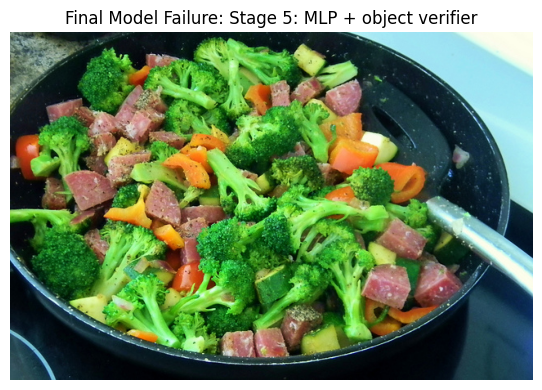

Correct caption:
No bowl is present in this image.

Predicted caption:
This image displays a bowl.

Correct index: 0
Predicted index: 2
Margin: -0.715674
Scores: [1.0278164161781453, -1.574488723641437, 1.7434903100687187, -1.1968180026054271]

Final Model Failure: Stage 5: MLP + object verifier | ex_id = 17
------------------------------------------------------------------------------------------


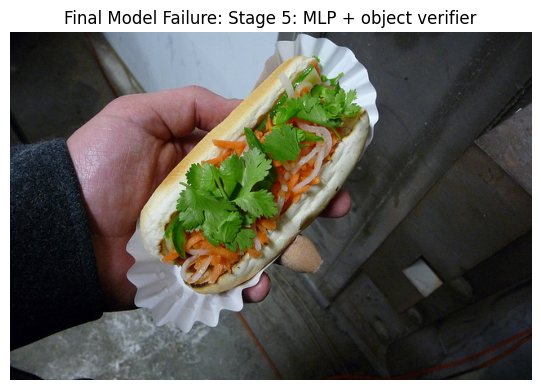

Correct caption:
A dining table is not present in this image.

Predicted caption:
There is no hot dog in this image.

Correct index: 0
Predicted index: 3
Margin: -0.035034
Scores: [0.3213995880997591, -0.7720749323926899, 0.09424148713866431, 0.3564338571542664]

Final Model Failure: Stage 5: MLP + object verifier | ex_id = 26
------------------------------------------------------------------------------------------


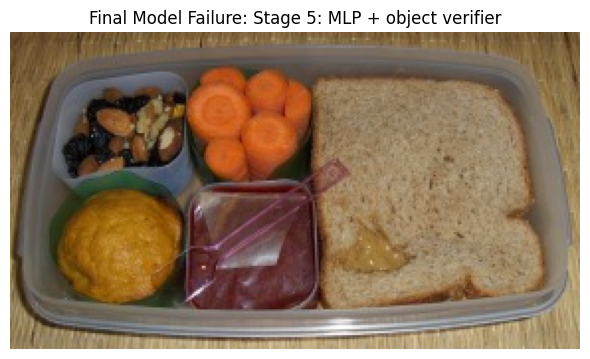

Correct caption:
A bowl is noticeably absent from this image.

Predicted caption:
A bowl is included in this image

Correct index: 0
Predicted index: 2
Margin: -0.533444
Scores: [0.7000520759869516, -1.9684370120525694, 1.2334961229458419, 0.034888813119775874]

Final Model Failure: Stage 5: MLP + object verifier | ex_id = 31
------------------------------------------------------------------------------------------


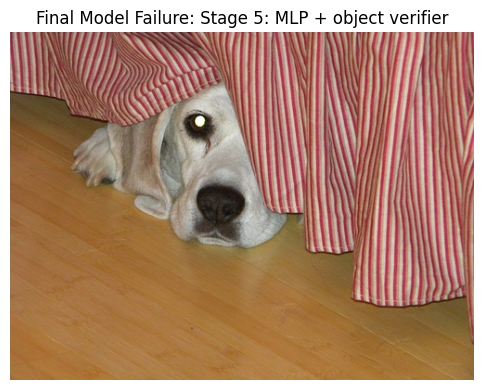

Correct caption:
A dog is present in this image, but no person is visible.

Predicted caption:
A person is included in this image, but there is no dog.

Correct index: 0
Predicted index: 1
Margin: -2.345246
Scores: [-1.0641760456400322, 1.2810695911216625, -0.1696167120622447, -0.04727683341938582]

Final Model Failure: Stage 5: MLP + object verifier | ex_id = 35
------------------------------------------------------------------------------------------


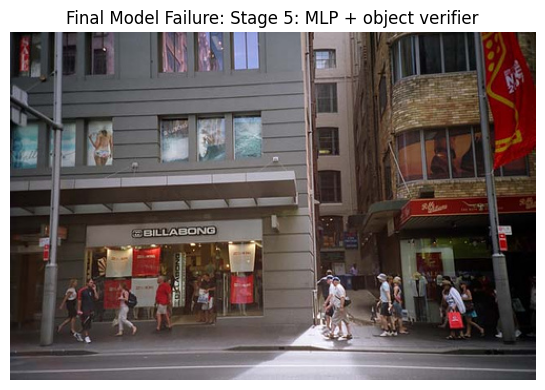

Correct caption:
This image shows a handbag, but no car is included.

Predicted caption:
A car is present, but there's no handbag in this image.

Correct index: 0
Predicted index: 1
Margin: -1.200882
Scores: [0.9327917875204588, 2.1336739221047516, -2.4483846607338, -0.6180810488914104]



In [ ]:
# ============================================================
# Save Final / Best Model Failure Cases
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Map model names to corresponding test result objects
# ------------------------------------------------------------

model_result_map = {
    "CLIP dual-encoder": clip_test,
    "Stage 1: Pairwise concat MLP": stage1_test,
    "Stage 2: Pairwise interaction MLP": stage2_test,
    "Stage 3: Listwise concat MLP": stage3_test,
}

# Optional models
if "blip_test" in globals() and RUN_BLIP:
    model_result_map["BLIP-ITM cross-encoder"] = blip_test

if "stage4_test" in globals():
    model_result_map["Stage 4: CLIP + Stage 1 ensemble"] = stage4_test

if "stage5_test" in globals():
    model_result_map["Stage 5: MLP + object verifier"] = stage5_test


# ------------------------------------------------------------
# 2. Select final model
#    If tied, prefer simpler model in this order.
# ------------------------------------------------------------

tie_preference = [
    "Stage 1: Pairwise concat MLP",
    "Stage 3: Listwise concat MLP",
    "Stage 5: MLP + object verifier",
    "Stage 4: CLIP + Stage 1 ensemble",
    "Stage 2: Pairwise interaction MLP",
    "CLIP dual-encoder",
    "BLIP-ITM cross-encoder",
]

best_acc = ablation_df["accuracy"].max()
candidate_models = ablation_df.loc[
    ablation_df["accuracy"] == best_acc,
    "model"
].tolist()

final_model = None
for m in tie_preference:
    if m in candidate_models:
        final_model = m
        break

# Fallback
if final_model is None:
    final_model = candidate_models[0]

final_test = model_result_map[final_model]

safe_final_model_name = (
    final_model
    .lower()
    .replace(":", "")
    .replace("+", "plus")
    .replace(" ", "_")
    .replace("/", "_")
)

print("Final selected model:", final_model)
print("Final model accuracy:", final_test["accuracy"])
print("Final model failures:", len(final_test["failures"]))


# ------------------------------------------------------------
# 3. Save failure cases
# ------------------------------------------------------------

final_failures_df = pd.DataFrame(final_test["failures"])

final_failures_path = os.path.join(
    OUTPUT_DIR,
    f"{safe_final_model_name}_failure_cases.csv"
)

final_failures_df.to_csv(final_failures_path, index=False)

print("Saved:", final_failures_path)
display(final_failures_df.head())


# ------------------------------------------------------------
# 4. Visualize failure cases
# ------------------------------------------------------------

def show_failure_cases(failure_df, n=5, title="Failure Case"):
    """
    Display qualitative failure cases.
    """
    if failure_df is None or len(failure_df) == 0:
        print("No failures.")
        return

    sample_df = failure_df.head(n)

    for idx, row in sample_df.iterrows():
        image_path = row["image_path"]

        print("=" * 90)
        print(f"{title} | ex_id = {row.get('ex_id', idx)}")
        print("-" * 90)

        if isinstance(image_path, str) and os.path.exists(image_path):
            img = Image.open(image_path).convert("RGB")

            plt.figure(figsize=(6, 4))
            plt.imshow(img)
            plt.axis("off")
            plt.title(title)
            plt.tight_layout()
            plt.show()
        else:
            print("Image not found:", image_path)

        print("Correct caption:")
        print(row["correct_caption"])

        print("\nPredicted caption:")
        print(row["pred_caption"])

        print("\nCorrect index:", row["correct_idx"])
        print("Predicted index:", row["pred_idx"])
        print("Margin:", round(float(row["margin"]), 6))

        if "scores" in row:
            print("Scores:", row["scores"])

        print("=" * 90)
        print()


show_failure_cases(
    final_failures_df,
    n=5,
    title=f"Final Model Failure: {final_model}"
)